In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
options(jupyter.rich_display = FALSE)

dir.create("../../outputs/Fig4", recursive = TRUE, showWarnings = FALSE)


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

## Step 1: Load Data

In [2]:
lucas_df <- read_csv("../../data/lucas_df_with_pcs.csv")

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Step 2: TFBS Traces

In [3]:
# ============================================================================
# calculate_coverage: Now supports "rpm", "fraction", "bp", "zscore", "binary"
# Optional: harmonize_width (e.g., 400L)
# ============================================================================

# ============================================================================
# CELL TYPE METADATA
# ============================================================================

suppressPackageStartupMessages({
  library(GenomicRanges)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(pheatmap)
    library(rtracklayer)

})

CELL_TYPE_INFO <- list(
  # scATAC types
  "Immune" = list(type = "scATAC", path = "../../methods_code/WG/ref/CRE_sites_QC/scATAC_sites_QC2/Immune_filtered.hg19.rds"),
  "Ubiquitous" = list(type = "scATAC", path = "../../methods_code/WG/ref/CRE_sites_QC/scATAC_sites_QC2/Ubiquitous_filtered.hg19.rds"),
  "Erythroid" = list(type = "scATAC", path = "../../methods_code/WG/ref/CRE_sites_QC/scATAC_sites_QC2/Erythroid_filtered.hg19.rds"),

  # TCGA types
  "LUAD" = list(type = "TCGA", path = "../../methods_code/WG/ref/CRE_sites_QC/TCGA_sites_QC2/LUAD_ATAC_Peaks_hg19_filtered.hg19.rds"),
  "LUSC" = list(type = "TCGA", path = "../../methods_code/WG/ref/CRE_sites_QC/TCGA_sites_QC2/LUSC_ATAC_Peaks_hg19_filtered.hg19.rds")
)


# Function to load a specific TF
load_tf <- function(tf_name, tfbs_dir = "../../methods_code/WG/ref/TFBS/indv/") {
  file_path <- file.path(tfbs_dir, paste0("tf_", tf_name, "_5k.bed"))
  import(file_path, format = "BED")
}

calculate_coverage <- function(
  atac_peaks, tf_sites,
  window = 5000, bin_size = 50,
  normalize = TRUE,
  method = c("rpm", "fraction", "bp", "zscore", "binary"),
  harmonize_width = NULL
) {

  method <- match.arg(method)

  # ------------------------------------------------------------
  # 1) Peak-width harmonization (optional)
  # ------------------------------------------------------------
  if (!is.null(harmonize_width)) {
    atac_peaks <- resize(atac_peaks, width = harmonize_width, fix = "center")
  }

  # ------------------------------------------------------------
  # 2) Precompute overlaps
  # ------------------------------------------------------------
  tf_ext <- resize(tf_sites, width = 2 * window + 1, fix = "center")
  overlaps <- findOverlaps(tf_ext, atac_peaks)

  positions <- seq(-window, window, by = bin_size)
  n_bins <- length(positions)

  cov_mat <- matrix(0, nrow = length(tf_sites), ncol = n_bins)

  # ------------------------------------------------------------
  # 3) Bin counting
  # ------------------------------------------------------------
  for (i in seq_along(tf_sites)) {
    pk <- subjectHits(overlaps)[queryHits(overlaps) == i]
    if (length(pk) == 0) next

    center <- start(tf_sites[i]) + (width(tf_sites[i]) - 1) / 2
    used_bins <- integer(0)  # for binary

    for (p in pk) {
      peak <- atac_peaks[p]
      s <- start(peak) - center
      e <- end(peak)   - center

      b1 <- max(1, ceiling((s + window) / bin_size) + 1)
      b2 <- min(n_bins, floor((e + window) / bin_size) + 1)

      if (b1 <= b2) {
        if (method == "binary") {
          used_bins <- union(used_bins, b1:b2)
        } else {
          cov_mat[i, b1:b2] <- cov_mat[i, b1:b2] + 1
        }
      }
    }

    if (method == "binary" && length(used_bins)) {
      cov_mat[i, used_bins] <- 1
    }
  }

  # ------------------------------------------------------------
  # 4) Normalization
  # ------------------------------------------------------------
  if (normalize) {
    
    if (method == "rpm") {
      f <- length(atac_peaks) / 1e6
      cov_mat <- cov_mat / f
      cat("  - Normalized by RPM\n")

    } else if (method == "fraction") {
      cov_mat <- cov_mat / length(atac_peaks)
      cat("  - Normalized by fraction of peaks\n")

    } else if (method == "bp") {
      bp <- sum(width(atac_peaks)) / 1e6
      cov_mat <- cov_mat / bp
      cat("  - Normalized by accessible bp (per million bp)\n")

    } else if (method == "zscore") {
      cov_mat <- t(scale(t(cov_mat)))
      cov_mat[is.na(cov_mat)] <- 0
      cat("  - Z-score normalized per TFBS\n")

    } else if (method == "binary") {
      cat("  - Binary occupancy (0/1), no scaling applied\n")
    }
  }

  # ------------------------------------------------------------
  # 5) Output tidy DF
  # ------------------------------------------------------------
  data.frame(
    tf_site  = rep(seq_len(nrow(cov_mat)), each = n_bins),
    position = rep(positions, times = nrow(cov_mat)),
    coverage = as.vector(t(cov_mat))
  )
}

# ============================================================================
# plot_tfbs_enrichment: advanced normalization, harmonization, ubiquitous-filter
# ============================================================================

sanitize_gr_metadata <- function(gr) {
  # Forbidden metadata names in GRanges
  forbidden <- c(
    "seqnames","ranges","strand","seqlevels","seqlengths",
    "isCircular","start","end","width","element"
  )
  
  meta_names <- colnames(mcols(gr))
  bad <- intersect(meta_names, forbidden)
  
  if (length(bad) > 0) {
    for (nm in bad) {
      new_nm <- paste0("meta_", nm)
      message("Renaming illegal metadata column '", nm, "' → '", new_nm, "'")
      mcols(gr)[[new_nm]] <- mcols(gr)[[nm]]
      mcols(gr)[[nm]] <- NULL
    }
  }
  
  return(gr)
}

plot_tfbs_enrichment <- function(
  cell_types,
  tf_name,
  reference_cell = NULL,
  window = 5000,
  bin_size = 50,
  tfbs_dir = "../../methods_code/WG/ref/TFBS/indv/",
  color_palette = "default",
  normalize = TRUE,
  norm_method = "rpm",
  harmonize_width = NULL,
  remove_ubiquitous = FALSE,          
  ubiquitous_path = "../../methods_code/WG/ref/CRE_sites_QC/scATAC_sites_QC2/Ubiquitous_filtered.hg19.rds"              
) {

  # ------------------------------------------------------------
  # Validation
  # ------------------------------------------------------------
  invalid <- setdiff(cell_types, names(CELL_TYPE_INFO))
  if (length(invalid) > 0)
    stop("Unknown cell types: ", paste(invalid, collapse = ", "))

  if (is.null(reference_cell)) {
    reference_cell <- cell_types[1]
    cat("Using", reference_cell, "as reference\n")
  }

  # ------------------------------------------------------------
  # Load TFBS
  # ------------------------------------------------------------
  cat("Loading TF:", tf_name, "\n")
  tf_sites <- load_tf(tf_name, tfbs_dir)
  cat("Loaded", length(tf_sites), "TF binding sites\n")

  # ------------------------------------------------------------
  # Coverage per cell type
  # ------------------------------------------------------------
  cov_list <- list()

  for (ct in cell_types) {
    cat("Processing", ct, "...\n")

    gr <- readRDS(CELL_TYPE_INFO[[ct]]$path)
    gr <- sanitize_gr_metadata(gr)
      
    # ------------------------------------------------------------
    # Remove ubiquitous peaks (optional & symmetric across all)
    # ------------------------------------------------------------
    if (remove_ubiquitous) {
      if (is.null(ubiquitous_path))
        stop("remove_ubiquitous=TRUE but no 'ubiquitous_path' provided.")

      ubiquitous_gr <- readRDS(ubiquitous_path)

      hits <- findOverlaps(gr, ubiquitous_gr)
      n_removed <- length(unique(queryHits(hits)))

      if (n_removed > 0) 
        gr <- gr[-unique(queryHits(hits))]

      cat("  - Removed", n_removed, "ubiquitous peaks\n")
    }

    # ------------------------------------------------------------
    # Compute normalized coverage
    # ------------------------------------------------------------
    cov_df <- calculate_coverage(
      atac_peaks      = gr,
      tf_sites        = tf_sites,
      window          = window,
      bin_size        = bin_size,
      normalize       = normalize,
      method          = norm_method,
      harmonize_width = harmonize_width
    )

    cov_df$condition <- ct
    cov_list[[ct]] <- cov_df

    cat("  -", length(gr), "peaks retained\n")
  }

  # Combine
  all_cov <- do.call(rbind, cov_list)

  # ------------------------------------------------------------
  # Axis label
  # ------------------------------------------------------------
  y_label <- dplyr::case_when(
    !normalize                 ~ "Mean ATAC-seq coverage",
    norm_method == "rpm"      ~ "Normalized coverage (CPM)",
    norm_method == "fraction" ~ "Normalized coverage (fraction)",
    norm_method == "bp"       ~ "Coverage per Mb accessible bp",
    norm_method == "zscore"   ~ "Z-scored coverage",
    norm_method == "binary"   ~ "Fraction of TFBS accessible (0–1)"
  )

  # ------------------------------------------------------------
  # Color palette
  # ------------------------------------------------------------
  palette_options <- list(
    default = c("#E64B35", "#4DBBD5", "#00A087", "#3C5488",
                "#F39B7F", "#8491B4", "#91D1C2", "#DC0000"),
    nature  = c("#E64B35", "#4DBBD5", "#00A087", "#3C5488",
                "#F39B7F", "#8491B4", "#91D1C2", "#DC0000"),
    lancet  = c("#00468B", "#ED0000", "#42B540", "#0099B4",
                "#925E9F", "#FDAF91", "#AD002A", "#ADB6B6"),
    jco     = c("#0073C2", "#EFC000", "#868686", "#CD534C",
                "#7AA6DC", "#003C67", "#8F7700", "#3B3B3B"),
    nejm    = c("#BC3C29", "#0072B5", "#E18727", "#20854E",
                "#7876B1", "#6F99AD", "#FFDC91", "#EE4C97")
  )

  # Safety check: avoid palette out-of-range
  n_ct <- length(cell_types)
  available_cols <- palette_options[[color_palette]]
  if (length(available_cols) < n_ct)
    stop("Palette '", color_palette, "' does not have enough colors for ", n_ct, " cell types.")

  colors <- setNames(available_cols[seq_len(n_ct)], cell_types)

  # ------------------------------------------------------------
  # Summary curves (mean ± SEM)
  # ------------------------------------------------------------
  summary_df <- all_cov %>%
    group_by(position, condition) %>%
    summarise(
      mean_cov = mean(coverage),
      sem      = sd(coverage) / sqrt(n()),
      .groups = "drop"
    )

  # ------------------------------------------------------------
  # Metaplot
  # ------------------------------------------------------------
  p_metaplot <- ggplot(summary_df,
                       aes(position, mean_cov, color = condition, fill = condition)) +
    geom_ribbon(aes(ymin = mean_cov - sem, ymax = mean_cov + sem),
                alpha = 0.15, color = NA) +
    geom_line(linewidth = 1.0) +
    scale_color_manual(values = colors) +
    scale_fill_manual(values = colors) +
    geom_vline(xintercept = 0, linetype = "dashed") +
    theme_classic(base_size = 11) +
    labs(
      x = paste0("Distance from ", tf_name, " motif (bp)"),
      y = y_label,
      title = paste0(tf_name, " binding-site accessibility")
    )

  # ------------------------------------------------------------
  # Enrichment curves vs reference cell
  # ------------------------------------------------------------
  mean_cov_tbl <- summary_df %>%
    transmute(position, condition, cov = mean_cov)

  ref_curve <- mean_cov_tbl %>% filter(condition == reference_cell)

  ratio_df <- bind_rows(lapply(setdiff(cell_types, reference_cell), function(ct) {
    cur <- mean_cov_tbl %>% filter(condition == ct)
    inner_join(cur, ref_curve, by = "position") %>%
      transmute(
        position,
        Comparison = paste0(ct, " vs ", reference_cell),
        Log2_Ratio = log2((cov.x + 0.1) / (cov.y + 0.1))
      )
  }))

  comp_cols <- setNames(
    colors[setdiff(cell_types, reference_cell)],
    paste0(setdiff(cell_types, reference_cell), " vs ", reference_cell)
  )

  p_enrichment <- ggplot(ratio_df,
                         aes(position, Log2_Ratio, color = Comparison)) +
    geom_hline(yintercept = 0, color = "grey40") +
    geom_line(linewidth = 1.0) +
    geom_vline(xintercept = 0, linetype = "dashed") +
    scale_color_manual(values = comp_cols) +
    theme_classic(base_size = 11) +
    labs(
      x = paste0("Distance from ", tf_name, " motif (bp)"),
      y = expression(bold(Log[2]~"enrichment")),
      title = paste0("Differential ", tf_name, " accessibility")
    )

  # ------------------------------------------------------------
  # Return objects
  # ------------------------------------------------------------
  list(
    metaplot       = p_metaplot,
    enrichment     = p_enrichment,
    coverage_data  = all_cov,
    summary_data   = summary_df,
    ratio_data     = ratio_df,
    colors         = colors,
    tf_name        = tf_name,
    reference_cell = reference_cell
  )
}



In [4]:
# ============================================================================
# MULTI-TF VERSION OF plot_tfbs_enrichment (styled)
# ============================================================================

plot_tfbs_enrichment <- function(
  cell_types,
  tf_names,
  reference_cell = NULL,
  window = 5000,
  bin_size = 50,
  tfbs_dir = "../../methods_code/WG/ref/TFBS/indv/",
  color_palette = "default",
  normalize = TRUE,
  norm_method = "rpm",
  harmonize_width = NULL,
  remove_ubiquitous = FALSE,
  ubiquitous_path = "../../methods_code/WG/ref/CRE_sites_QC/scATAC_sites_QC2/Ubiquitous_filtered.hg19.rds",
  plot_style = c("combined", "facet"),
  ncol = 2,
  base_size = 14,
  return_list = FALSE
) {

  plot_style <- match.arg(plot_style)

  # ------------------------------------------------------------
  # Validation
  # ------------------------------------------------------------
  invalid <- setdiff(cell_types, names(CELL_TYPE_INFO))
  if (length(invalid) > 0)
    stop("Unknown cell types: ", paste(invalid, collapse = ", "))

  if (is.null(reference_cell)) {
    reference_cell <- cell_types[1]
    cat("Using", reference_cell, "as reference\n")
  }

  # ------------------------------------------------------------
  # Load & preprocess ATAC peaks ONCE per cell type
  # ------------------------------------------------------------
  atac_store <- list()

  for (ct in cell_types) {
    cat("Processing peaks for:", ct, "\n")

    gr <- readRDS(CELL_TYPE_INFO[[ct]]$path)
    gr <- sanitize_gr_metadata(gr)

    # Remove ubiquitous
    if (remove_ubiquitous) {
      ubi <- readRDS(ubiquitous_path)
      hits <- findOverlaps(gr, ubi)
      if (length(hits) > 0) {
        gr <- gr[-unique(queryHits(hits))]
        cat("  - Removed", length(unique(queryHits(hits))), "ubiquitous peaks\n")
      }
    }

    # Harmonize width
    if (!is.null(harmonize_width)) {
      gr <- resize(gr, width = harmonize_width, fix = "center")
    }

    atac_store[[ct]] <- gr
  }

  # ------------------------------------------------------------
  # Storage for all-TF results
  # ------------------------------------------------------------
  tf_results <- list()

  # ------------------------------------------------------------
  # Process each TF
  # ------------------------------------------------------------
  for (tf_name in tf_names) {

    cat("Loading TF:", tf_name, "\n")
    tf_sites <- load_tf(tf_name, tfbs_dir)
    cat("Loaded", length(tf_sites), "TF binding sites\n")

    cov_list <- list()

    # Coverage for each cell type
    for (ct in cell_types) {

      gr <- atac_store[[ct]]

      cov_df <- calculate_coverage(
        atac_peaks      = gr,
        tf_sites        = tf_sites,
        window          = window,
        bin_size        = bin_size,
        normalize       = normalize,
        method          = norm_method
      )

      cov_df$condition <- ct
      cov_list[[ct]] <- cov_df
    }

    # Combine coverage for this TF
    all_cov <- do.call(rbind, cov_list)

    # Summary curves
    summary_df <- all_cov %>%
      group_by(position, condition) %>%
      summarise(
        mean_cov = mean(coverage),
        sem      = sd(coverage) / sqrt(n()),
        .groups = "drop"
      )

    # Store for this TF
    tf_results[[tf_name]] <- list(
      coverage_data = all_cov,
      summary_data  = summary_df
    )
  }

  # ------------------------------------------------------------
  # Prepare global plotting objects
  # ------------------------------------------------------------
  y_label <- dplyr::case_when(
    !normalize                 ~ "Mean ATAC-seq coverage",
    norm_method == "rpm"      ~ "Normalized coverage (CPM)",
    norm_method == "fraction" ~ "Normalized coverage (fraction)",
    norm_method == "bp"       ~ "Coverage per Mb accessible bp",
    norm_method == "zscore"   ~ "Z-scored coverage",
    norm_method == "binary"   ~ "Fraction of TFBS accessible (0–1)"
  )

  # palettes
  palette_options <- list(
    default = c("#E64B35", "#4DBBD5", "#00A087", "#3C5488",
                "#F39B7F", "#8491B4", "#91D1C2", "#DC0000"),
    nature  = c("#E64B35", "#4DBBD5", "#00A087", "#3C5488",
                "#F39B7F", "#8491B4", "#91D1C2", "#DC0000"),
    lancet  = c("#00468B", "#ED0000", "#42B540", "#0099B4",
                "#925E9F", "#FDAF91", "#AD002A", "#ADB6B6"),
    jco     = c("#0073C2", "#EFC000", "#868686", "#CD534C",
                "#7AA6DC", "#003C67", "#8F7700", "#3B3B3B"),
    nejm    = c("#BC3C29", "#0072B5", "#E18727", "#20854E",
                "#7876B1", "#6F99AD", "#FFDC91", "#EE4C97")
  )

  colors <- palette_options[[color_palette]]
  if (length(colors) < length(cell_types))
    stop("Not enough colors for cell types.")

  colors <- setNames(colors[seq_len(length(cell_types))], cell_types)

  # Define legend order
 legend_order <- cell_types

  # ============================================================================
  # PLOT STYLE 1: Combined TF Curves
  # ============================================================================

  if (plot_style == "combined") {

    library(ggplot2)

    df_combined <- do.call(rbind, lapply(names(tf_results), function(tf) {
      df <- tf_results[[tf]]$summary_data
      df$TF <- tf
      df
    }))

    tf_cols <- setNames(scales::hue_pal()(length(tf_names)), tf_names)

    p_combined <- ggplot(df_combined,
                         aes(position, mean_cov, color = TF)) +
      geom_line(linewidth = 1.0) +
      theme_classic(base_size = base_size) +
      labs(
        x = "Distance from motif center (bp)",
        y = y_label,
        title = paste("TFBS Metaplot:", paste(tf_names, collapse=", "))
      ) +
      scale_color_manual(values = tf_cols) +
      theme(
        legend.position = "top",
        legend.title    = element_blank(),
        plot.title      = element_text(face = "bold", size = 18),
        axis.title.x    = element_text(size = 16, face = "bold"),
        axis.title.y    = element_text(size = 16, face = "bold"),
        axis.text.x     = element_text(size = 14),
        axis.text.y     = element_text(size = 14),
        legend.text     = element_text(size = 14),
        legend.key.size = unit(1.2, "cm")
      )

    return(list(
      combined_plot = p_combined,
      tf_results = tf_results
    ))
  }


  # ============================================================================
  # PLOT STYLE 2: Faceted per-TF Plots
  # ============================================================================

  library(patchwork)

  tf_plots <- lapply(names(tf_results), function(tf) {

    df <- tf_results[[tf]]$summary_data
    
    # Set legend order
    df <- df %>%
      mutate(condition = factor(condition, levels = legend_order))

    ggplot(df,
           aes(position, mean_cov, color = condition, fill = condition)) +
      geom_ribbon(aes(ymin = mean_cov - sem, ymax = mean_cov + sem),
                  alpha = 0.15, color = NA) +
      geom_line(linewidth = 1.0) +
      scale_color_manual(values = colors, breaks = legend_order) +
      scale_fill_manual(values = colors, breaks = legend_order) +
      theme_classic(base_size = base_size) +
      theme(
        legend.position = "top",
        legend.title    = element_blank(),
        plot.title      = element_blank(),
        axis.title.x    = element_text(size = 30),
        axis.title.y    = element_text(size = 30),
        axis.text.x     = element_text(size = 25),
        axis.text.y     = element_text(size = 25),
        legend.text     = element_text(size = 25),
        legend.key.size = unit(1.2, "cm")
      ) +
      labs(
        x = "Distance from TFBS (bp)",
        y = y_label,
        title = tf
      )
  })
  
  names(tf_plots) <- tf_names

  # Return list or combined plot
  if (return_list) {
    return(list(
      plot_list = tf_plots,
      tf_results = tf_results
    ))
  } else {
    p_faceted <- wrap_plots(tf_plots, ncol = ncol)
    return(list(
      faceted_plot = p_faceted,
      tf_results = tf_results
    ))
  }
}

Using LUAD as reference
Processing peaks for: LUAD 
  - Removed 25201 ubiquitous peaks
Processing peaks for: Immune 


Renaming illegal metadata column 'strand' → 'meta_strand'



  - Removed 14 ubiquitous peaks
Processing peaks for: LUSC 
  - Removed 22912 ubiquitous peaks
Processing peaks for: Erythroid 


Renaming illegal metadata column 'strand' → 'meta_strand'



  - Removed 2 ubiquitous peaks
Loading TF: FOXA1 
Loaded 5000 TF binding sites
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
Loading TF: GRHL2 
Loaded 5000 TF binding sites
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)



Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area




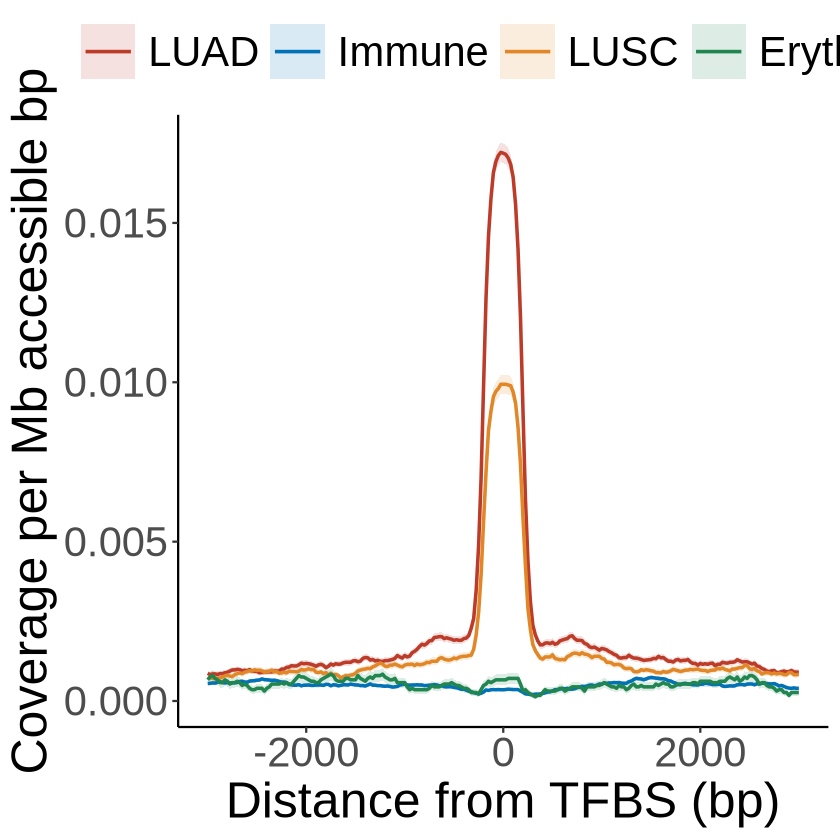

In [5]:
# Get individual plots
out2 <- plot_tfbs_enrichment(
  cell_types = c("LUAD", "Immune", "LUSC", "Erythroid"),
  tf_names   = c("FOXA1", "GRHL2"),
  normalize  = TRUE,
  norm_method = "bp",
  window = 3000,
  bin_size = 25,
  color_palette = "nejm",
  harmonize_width = 400L,
  remove_ubiquitous = TRUE,
  ncol = 2,
  plot_style = "facet",
  base_size = 14,
  return_list = TRUE
)

# Access individual plots
out2$plot_list[["FOXA1"]]


Using LUAD as reference
Processing peaks for: LUAD 
  - Removed 25201 ubiquitous peaks
Processing peaks for: Immune 


Renaming illegal metadata column 'strand' → 'meta_strand'



  - Removed 14 ubiquitous peaks
Processing peaks for: LUSC 
  - Removed 22912 ubiquitous peaks
Processing peaks for: Erythroid 


Renaming illegal metadata column 'strand' → 'meta_strand'



  - Removed 2 ubiquitous peaks
Loading TF: LYL1 
Loaded 5000 TF binding sites
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
Loading TF: MECOM 
Loaded 5000 TF binding sites
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)
  - Normalized by accessible bp (per million bp)


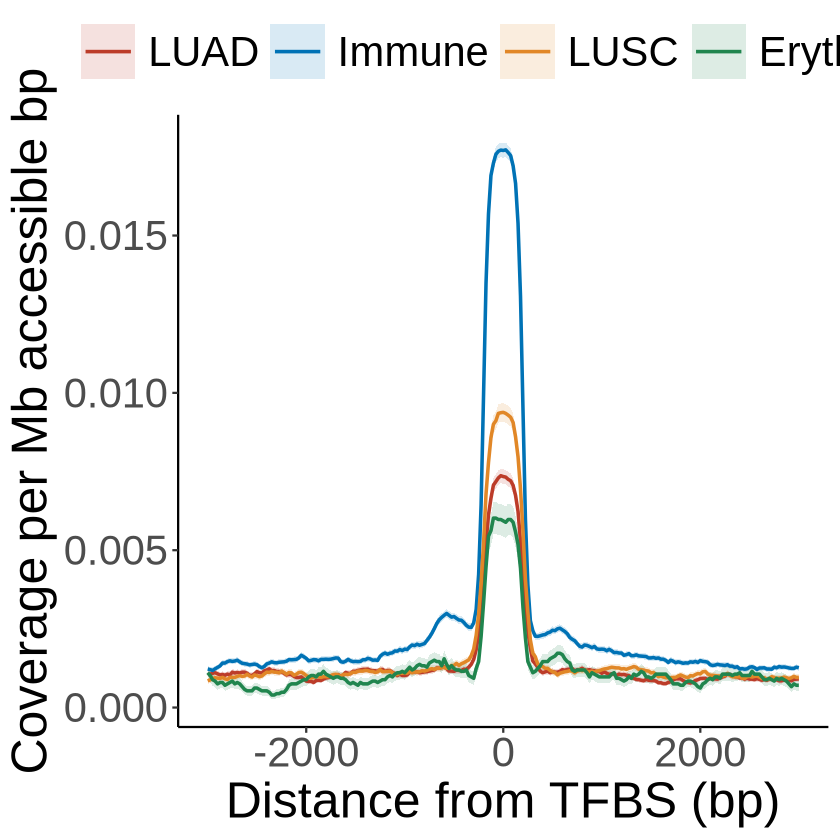

In [6]:
# Get individual plots
out3 <- plot_tfbs_enrichment(
  cell_types = c("LUAD", "Immune", "LUSC", "Erythroid"),
  tf_names   = c("LYL1", "MECOM"),
  normalize  = TRUE,
  norm_method = "bp",
  window = 3000,
  bin_size = 25,
  color_palette = "nejm",
  harmonize_width = 400L,
  remove_ubiquitous = TRUE,
  ncol = 2,
  plot_style = "facet",
  base_size = 14,
  return_list = TRUE
)

# Access individual plots
out3$plot_list[["LYL1"]]

In [7]:
ggsave(
  filename = "../../outputs/Fig4/Fig-Access-ATAC-FOXA1.png",
  plot = out2$plot_list[["FOXA1"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

ggsave(
  filename = "../../outputs/Fig4/Fig-Access-ATAC-GRHL2.png",
  plot = out2$plot_list[["GRHL2"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

ggsave(
  filename = "../../outputs/Fig4/Fig-Access-ATAC-LYL1.png",
  plot = out3$plot_list[["LYL1"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)


ggsave(
  filename = "../../outputs/Fig4/Fig-Access-ATAC-MECOM.png",
  plot = out3$plot_list[["MECOM"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

## Step 3: Cell-free DNA Footprint Analyses

### To generate relevant figures, skip this analysis block to the section title "Begin Here"

In [9]:
suppressPackageStartupMessages({
  library(GenomicRanges)
  library(IRanges)
  library(Biostrings)
  library(BSgenome.Hsapiens.UCSC.hg19)
  library(rtracklayer)
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
})

HG19_GENOME <- BSgenome.Hsapiens.UCSC.hg19

# Default fragment directory (you can override in function call)
fragDir <- "../../methods_code/WG/results/corrected-LUCAS/"

BLACKLIST_FILE    <- "../../methods_code/WG/scripts/PlasmaTools/data/filters.hg19.rda"
GC_TARGET_HISEQ   <- "../../methods_code/WG/scripts/reference_files/target-hiseq.tsv"
GC_TARGET_NOVASEQ <- "../../methods_code/WG/scripts/reference_files/target-novaseq.tsv"

load(BLACKLIST_FILE)   # loads `filters.hg19`

select_gc_target <- function(platform) {
  platform <- tolower(platform)
  switch(platform,
         "hiseq"   = GC_TARGET_HISEQ,
         "novaseq" = GC_TARGET_NOVASEQ,
         stop("platform must be 'hiseq' or 'novaseq'"))
}

###############################################################################
#  LOAD cfDNA FRAGMENTS
###############################################################################

load_cfdna_fragments <- function(frag_path,
                                 frag_min = 100,
                                 frag_max = 220,
                                 valid_chroms = paste0("chr", c(1:22,"X","Y"))) {

  cat("Loading:", basename(frag_path), "\n"); flush.console()

  frag <- if (grepl("\\.starch$", frag_path)) {
    unstarch_to_granges(frag_path, tmpdir = tempdir())
  } else {
    readRDS(frag_path)
  }

  seqlevelsStyle(frag) <- "UCSC"

  frag <- frag[seqnames(frag) %in% valid_chroms]
  frag <- frag[width(frag) >= frag_min & width(frag) <= frag_max]

  if (!length(frag)) stop("No fragments remain after filtering.")
  frag
}

###############################################################################
#  BLACKLIST
###############################################################################

apply_blacklist_filter <- function(frag, blacklist) {
  keep <- is.na(findOverlaps(frag, blacklist, select="first"))
  frag <- frag[keep]
  cat("  After blacklist:", length(frag), "fragments\n"); flush.console()
  frag
}

###############################################################################
#  GC CORRECTION
###############################################################################

apply_gc_correction <- function(frag, GC_TARGET, genome = HG19_GENOME) {

  cat("  GC correction...\n"); flush.console()

  seqs <- getSeq(genome, frag)
  gc_counts <- rowSums(letterFrequency(seqs, c("G","C")))
  gc_frac <- gc_counts / width(frag)

  keep_gc <- gc_frac >= 0.20 & gc_frac <= 0.80
  if (!any(keep_gc)) stop("All fragments removed by GC-range filtering.")
  frag <- frag[keep_gc]
  gc_frac <- gc_frac[keep_gc]

  gc_bin <- round(gc_frac, 2)

  dt <- data.table(chr = as.character(seqnames(frag)),
                   gc  = gc_bin,
                   idx = seq_along(frag))

  # Normalize GC_TARGET
  GC_TARGET[, chr := as.character(chr)]
  GC_TARGET[, gc  := round(as.numeric(gc), 2)]
  GC_TARGET[, target := as.numeric(target)]
  GC_TARGET <- GC_TARGET[gc >= 0.20 & gc <= 0.80]

  obs <- dt[, .N, by = .(chr, gc)]
  setnames(obs, "N", "n")

  merged <- merge(obs, GC_TARGET, by = c("chr","gc"), all.x = TRUE)
  merged <- merged[!is.na(target)]
  merged[, weight := target / n]

  m <- merge(dt, merged, by = c("chr","gc"), all.x = TRUE)

  keep <- !is.na(m$weight)
  if (!any(keep)) stop("All fragments lost after GC weighting.")

  frag <- frag[m$idx[keep]]
  m    <- m[keep]

  mcols(frag)$gc_bin <- m$gc
  mcols(frag)$weight <- m$weight

  cat("  GC correction retained:", length(frag), "\n"); flush.console()
  frag
}

###############################################################################
#  COVERAGE
###############################################################################

compute_weighted_coverage <- function(frag) {
  coverage(frag, weight = mcols(frag)$weight)
}

###############################################################################
#  LOAD TFBS (CACHED)
###############################################################################

.tf_cache <- new.env()

load_tf <- function(tf_name,
                    tfbs_dir = "../../methods_code/WG/ref/TFBS/indv/") {

  if (exists(tf_name, envir = .tf_cache))
    return(.tf_cache[[tf_name]])

  tf_clean <- toupper(tf_name)
  file_path <- file.path(tfbs_dir, paste0("tf_", tf_clean, "_5k.bed"))

  if (!file.exists(file_path))
    stop("Missing TFBS file: ", file_path)

  gr <- import(file_path, format = "BED")
  seqlevelsStyle(gr) <- "UCSC"
  .tf_cache[[tf_name]] <- gr
  gr
}

###############################################################################
#  HISTOLOGY MAP
###############################################################################

histology_to_group <- function(x) {
  x <- trimws(x)
  dplyr::case_when(
    x %in% c("Benign", "No baseline cancer") ~ "Healthy",
    x == "Adenocarcinoma"                    ~ "Adenocarcinoma",
    x == "Squamous"                          ~ "Squamous",
    x == "SCLC"                              ~ "SCLC",
    TRUE ~ NA_character_
  )
}


In [10]:
lucas_df <- lucas_df[!is.na(lucas_df$id) & lucas_df$id != "", ]

In [11]:
suppressPackageStartupMessages({
  library(dplyr)
  library(data.table)
  library(ggplot2)
  library(patchwork)
})

options(stringsAsFactors = FALSE)

###############################################################################
#  HELPER: MAP clinical histology → Group
###############################################################################
histology_to_group <- function(x) {
  x <- trimws(as.character(x))
  dplyr::case_when(
    x %in% c("Benign", "No baseline cancer") ~ "Healthy",
    x == "Adenocarcinoma"                    ~ "Adenocarcinoma",
    x == "Squamous"                          ~ "Squamous",
    x == "SCLC"                              ~ "SCLC",
    TRUE ~ NA_character_
  )
}


plot_tfbs_enrichment_cfdna5_cache <- function(
  lucas_df,
  cacheDir,
  tf_names,
  patient_types = c("Healthy","Adenocarcinoma","Squamous","SCLC"),
  stage_filter = NULL,
  ichor_min = NULL,
  ichor_max = NULL,
  platform = "hiseq",
  plot_ncol = 2,
  normalize = c("none","center","zscore","flank"),
  max_samples_per_group = NULL        # <======= NEW ARG
) {

  normalize <- match.arg(normalize)
  cat("====== Starting TF accessibility pipeline (per-TF files) ======\n")

  lucas_df <- as.data.frame(lucas_df)

  ###############################################################################
  # 1. HISTOLOGY FILTER
  ###############################################################################
  hist_col <- grep("histo|Histo|Histology|histology|path|Path|diagn|Diag",
                   names(lucas_df), value = TRUE)[1]
  if (is.na(hist_col)) stop("❌ No histology column found.")

  lucas_df$Group <- histology_to_group(lucas_df[[hist_col]])
  lucas_df <- lucas_df[lucas_df$Group %in% patient_types, ]
  if (nrow(lucas_df) == 0) stop("❌ No samples after histology filter.")

  ###############################################################################
  # 2. ICHOR FILTER — APPLY ONLY TO CANCER, NOT HEALTHY
  ###############################################################################
  ichor_col <- grep("ichor|Ichor|ICHOR|ichorCNA|IchorCNA",
                    names(lucas_df), value = TRUE)[1]

  if (!is.null(ichor_col)) {

    cancer_idx <- lucas_df$Group != "Healthy"

    if (!is.null(ichor_min)) {
      lucas_df <- lucas_df[
        (!cancer_idx) | (lucas_df[[ichor_col]] >= ichor_min),
      ]
    }

    if (!is.null(ichor_max)) {
      lucas_df <- lucas_df[
        (!cancer_idx) | (lucas_df[[ichor_col]] <= ichor_max),
      ]
    }
  }

  if (nrow(lucas_df) == 0) stop("❌ No samples after ichor filtering.")

  ###############################################################################
  # 3. FIND SAMPLE DIRECTORIES
  ###############################################################################
  lucas_df$sample_dir <- sapply(lucas_df$id, function(pid) {
    d <- file.path(cacheDir, pid)
    if (dir.exists(d)) return(d)
    cat("WARNING: no folder for ID:", pid, "\n")
    return(NA)
  })

  lucas_df <- lucas_df[!is.na(lucas_df$sample_dir), ]
  if (nrow(lucas_df) == 0) stop("❌ No valid sample directories found.")

  ###############################################################################
  # 3b. OPTIONAL: BALANCED SUBSAMPLING BY GROUP
  ###############################################################################
  if (!is.null(max_samples_per_group)) {

    if (!is.numeric(max_samples_per_group) || max_samples_per_group <= 0)
      stop("❌ max_samples_per_group must be a positive integer.")

    cat("Applying group-balanced subsampling (max =", max_samples_per_group, "per group)\n")

    split_groups <- split(lucas_df, lucas_df$Group)

    subsampled_groups <- lapply(split_groups, function(dfgrp) {
      if (nrow(dfgrp) > max_samples_per_group) {
        dfgrp[sample(seq_len(nrow(dfgrp)), max_samples_per_group), ]
      } else dfgrp
    })

    lucas_df <- do.call(rbind, subsampled_groups)
    rownames(lucas_df) <- NULL

    cat("  Samples retained per group:\n")
    print(table(lucas_df$Group))
  }

  ###############################################################################
  # 4. MAIN LOOP ACROSS TFs
  ###############################################################################
  tf_results <- list()

  for (tf in tf_names) {

    tf_lower <- tolower(tf)
    tf_file  <- paste0("tf_", tf_lower, ".rds")

    cat("TF:", tf, "\n")
    per_patient_list <- list()

    ###########################################################################
    # LOAD EACH PATIENT'S TF WEIGHTED COVERAGE MATRIX
    ###########################################################################
    for (i in seq_len(nrow(lucas_df))) {

      pid  <- lucas_df$id[i]
      sdir <- lucas_df$sample_dir[i]

      tf_path   <- file.path(sdir, tf_file)
      meta_path <- file.path(sdir, "metadata.rds")

      if (!file.exists(tf_path)) {
        cat("  Missing TF file for:", pid, "\n")
        next
      }
      if (!file.exists(meta_path))
        stop("Missing metadata.rds in ", sdir)

      M        <- readRDS(tf_path)
      metadata <- readRDS(meta_path)

      nbins  <- ncol(M)
      window <- metadata$window
      pos    <- seq(-window, window, length.out = nbins)

      dt <- as.data.table(M)
      setnames(dt, paste0("bin", seq_len(nbins)))
      dt[, tf_site := .I]

      dt_long <- melt(
        dt,
        id.vars = "tf_site",
        variable.name = "bin",
        value.name = "coverage"
      )

      dt_long[, bin      := as.integer(sub("bin", "", bin))]
      dt_long[, position := pos[bin]]
      dt_long[, Patient  := pid]
      dt_long[, Group    := lucas_df$Group[i]]

      ###########################################################################
      # NORMALIZATION
      ###########################################################################
      if (normalize == "center") {
        mu <- mean(dt_long$coverage, na.rm = TRUE)
        dt_long[, coverage := coverage - mu]
      }

      if (normalize == "zscore") {
        mu  <- mean(dt_long$coverage, na.rm = TRUE)
        sdv <- sd(dt_long$coverage, na.rm = TRUE)
        dt_long[, coverage := (coverage - mu) / sdv]
      }

      if (normalize == "flank") {
        flank_idx  <- abs(dt_long$position) >= 1000
        flank_mean <- mean(dt_long[flank_idx]$coverage, na.rm = TRUE)
        dt_long[, coverage := coverage - flank_mean]
      }

      per_patient_list[[length(per_patient_list) + 1]] <- dt_long
    }

    if (length(per_patient_list) == 0) {
      tf_results[[tf]] <- list(summary = data.table())
      next
    }

    df_all <- rbindlist(per_patient_list)

    ###############################################################################
    # QC: Remove low-quality bins
    ###############################################################################
    pos_qc <- df_all[, .(
      na_frac   = mean(is.na(coverage)),
      zero_frac = mean(coverage == 0, na.rm = TRUE),
      var_cov   = var(coverage, na.rm = TRUE)
    ), by = position]

    good_pos <- pos_qc[
      na_frac   < 0.5 &
      zero_frac < 0.5 &
      var_cov   > 1e-8
    ]$position

    df_all <- df_all[position %in% good_pos]

    ###############################################################################
    # GROUP SUMMARY (mean ± SEM)
    ###############################################################################
    summary_df <- df_all[, .(
      mean_cov = mean(coverage, na.rm = TRUE),
      sem      = sd(coverage,   na.rm = TRUE) / sqrt(.N)
    ), by = .(position, Group)]

    tf_results[[tf]] <- list(summary = summary_df)
  }

  ###############################################################################
  # 5. PLOTTING
  ###############################################################################
  plot_list <- lapply(tf_names, function(tf) {
    df <- tf_results[[tf]]$summary
    if (!nrow(df)) {
      return(ggplot() + theme_void() + ggtitle(paste(tf, "(no data)")))
    }

    ggplot(df, aes(position, mean_cov, color = Group, fill = Group)) +
      geom_ribbon(aes(ymin = mean_cov - sem,
                      ymax = mean_cov + sem),
                  alpha = 0.20, color = NA) +
      geom_line(linewidth = 1.2) +
      theme_classic(base_size = 14) +
      theme(
        legend.position = "top",
        legend.title    = element_blank()
      ) +
      labs(
        title = paste0("TF: ", tf),
        x = "Distance from motif (bp)",
        y = "Normalized cfDNA accessibility"
      )
  })

  final_plot <- wrap_plots(plot_list, ncol = plot_ncol)

  list(
    plot       = final_plot,
    tf_results = tf_results,
    patients   = lucas_df
  )
}


In [12]:
suppressPackageStartupMessages({
  library(dplyr)
  library(data.table)
  library(ggplot2)
  library(patchwork)
})

options(stringsAsFactors = FALSE)

histology_to_group <- function(x) {
  x <- trimws(as.character(x))
  dplyr::case_when(
    x %in% c("Benign", "No baseline cancer") ~ "Healthy",
    x == "Adenocarcinoma"                    ~ "Adenocarcinoma",
    x == "Squamous"                          ~ "Squamous",
    x == "SCLC"                              ~ "SCLC",
    TRUE ~ NA_character_
  )
}

plot_tfbs_enrichment_cfdna5_cache <- function(
  lucas_df,
  cacheDir,
  tf_names,
  patient_types = c("Healthy","Adenocarcinoma","Squamous","SCLC"),
  stage_filter = NULL,
  ichor_min = NULL,
  ichor_max = NULL,
  platform = "hiseq",
  plot_ncol = 2,
  normalize = c("none","center","zscore","flank"),
  max_samples_per_group = NULL
) {

  normalize <- match.arg(normalize)
  cat("====== Starting TF accessibility pipeline (per-TF files) ======\n")

  lucas_df <- as.data.frame(lucas_df)

  ###############################################################################
  # 1. HISTOLOGY FILTER
  ###############################################################################
  hist_col <- grep("histo|Histo|Histology|histology|path|Path|diagn|Diag",
                   names(lucas_df), value = TRUE)[1]
  if (is.na(hist_col)) stop("❌ No histology column found.")

  lucas_df$Group <- histology_to_group(lucas_df[[hist_col]])
  lucas_df <- lucas_df[lucas_df$Group %in% patient_types, ]
  if (nrow(lucas_df) == 0) stop("❌ No samples after histology filter.")

  ###############################################################################
  # 2. ICHOR FILTER
  ###############################################################################
  ichor_col <- grep("ichor|Ichor|ICHOR|ichorCNA|IchorCNA",
                    names(lucas_df), value = TRUE)[1]

  if (!is.null(ichor_col)) {
    cancer_idx <- lucas_df$Group != "Healthy"
    if (!is.null(ichor_min)) {
      lucas_df <- lucas_df[(!cancer_idx) | (lucas_df[[ichor_col]] >= ichor_min), ]
    }
    if (!is.null(ichor_max)) {
      lucas_df <- lucas_df[(!cancer_idx) | (lucas_df[[ichor_col]] <= ichor_max), ]
    }
  }

  if (nrow(lucas_df) == 0) stop("❌ No samples after ichor filtering.")

  ###############################################################################
  # 3. FIND SAMPLE DIRECTORIES
  ###############################################################################
  lucas_df$sample_dir <- sapply(lucas_df$id, function(pid) {
    d <- file.path(cacheDir, pid)
    if (dir.exists(d)) return(d)
    cat("WARNING: no folder for ID:", pid, "\n")
    return(NA)
  })

  lucas_df <- lucas_df[!is.na(lucas_df$sample_dir), ]
  if (nrow(lucas_df) == 0) stop("❌ No valid sample directories found.")

  ###############################################################################
  # 3b. BALANCED SUBSAMPLING
  ###############################################################################
  if (!is.null(max_samples_per_group)) {
    if (!is.numeric(max_samples_per_group) || max_samples_per_group <= 0)
      stop("❌ max_samples_per_group must be a positive integer.")

    cat("Applying group-balanced subsampling (max =", max_samples_per_group, "per group)\n")

    split_groups <- split(lucas_df, lucas_df$Group)
    subsampled_groups <- lapply(split_groups, function(dfgrp) {
      if (nrow(dfgrp) > max_samples_per_group) {
        dfgrp[sample(seq_len(nrow(dfgrp)), max_samples_per_group), ]
      } else dfgrp
    })

    lucas_df <- do.call(rbind, subsampled_groups)
    rownames(lucas_df) <- NULL

    cat("  Samples retained per group:\n")
    print(table(lucas_df$Group))
  }

  ###############################################################################
  # 4. MAIN LOOP ACROSS TFs
  ###############################################################################
  tf_results <- list()

  for (tf in tf_names) {

    tf_lower <- tolower(tf)
    tf_file  <- paste0("tf_", tf_lower, ".rds")

    cat("TF:", tf, "\n")
    per_patient_list <- list()

    ###########################################################################
    # LOAD EACH PATIENT'S TF WEIGHTED COVERAGE MATRIX
    ###########################################################################
    for (i in seq_len(nrow(lucas_df))) {

      pid  <- lucas_df$id[i]
      sdir <- lucas_df$sample_dir[i]

      tf_path   <- file.path(sdir, tf_file)
      meta_path <- file.path(sdir, "metadata.rds")

      if (!file.exists(tf_path)) {
        cat("  Missing TF file for:", pid, "\n")
        next
      }
      if (!file.exists(meta_path))
        stop("Missing metadata.rds in ", sdir)

      M        <- readRDS(tf_path)
      metadata <- readRDS(meta_path)

      nbins  <- ncol(M)
      window <- metadata$window
      pos    <- seq(-window, window, length.out = nbins)

      dt <- as.data.table(M)
      setnames(dt, paste0("bin", seq_len(nbins)))
      dt[, tf_site := .I]

      dt_long <- melt(
        dt,
        id.vars = "tf_site",
        variable.name = "bin",
        value.name = "coverage"
      )

      dt_long[, bin      := as.integer(sub("bin", "", bin))]
      dt_long[, position := pos[bin]]
      dt_long[, Patient  := pid]
      dt_long[, Group    := lucas_df$Group[i]]

      ###########################################################################
      # NORMALIZATION
      ###########################################################################
      if (normalize == "center") {
        mu <- mean(dt_long$coverage, na.rm = TRUE)
        dt_long[, coverage := coverage - mu]
      }

      if (normalize == "zscore") {
        mu  <- mean(dt_long$coverage, na.rm = TRUE)
        sdv <- sd(dt_long$coverage, na.rm = TRUE)
        dt_long[, coverage := (coverage - mu) / sdv]
      }

      if (normalize == "flank") {
        flank_idx  <- abs(dt_long$position) >= 1000
        flank_mean <- mean(dt_long[flank_idx]$coverage, na.rm = TRUE)
        dt_long[, coverage := coverage - flank_mean]
      }

      per_patient_list[[length(per_patient_list) + 1]] <- dt_long
    }

    if (length(per_patient_list) == 0) {
      tf_results[[tf]] <- list(
        summary          = data.table(),
        patient_summary  = data.table()
      )
      next
    }

    df_all <- rbindlist(per_patient_list)

    ###############################################################################
    # QC: Remove low-quality bins
    ###############################################################################
    pos_qc <- df_all[, .(
      na_frac   = mean(is.na(coverage)),
      zero_frac = mean(coverage == 0, na.rm = TRUE),
      var_cov   = var(coverage, na.rm = TRUE)
    ), by = position]

    good_pos <- pos_qc[
      na_frac   < 0.5 &
      zero_frac < 0.5 &
      var_cov   > 1e-8
    ]$position

    df_all <- df_all[position %in% good_pos]

    ###############################################################################
    # STEP 1: Patient-level mean across binding sites
    # This collapses the 5,000 sites into one value per patient per position
    ###############################################################################
    patient_summary <- df_all[, .(
      mean_cov = mean(coverage, na.rm = TRUE)
    ), by = .(position, Group, Patient)]

    ###############################################################################
    # STEP 2: Group-level summary across patients
    # SEM now reflects variability between biological replicates (patients)
    ###############################################################################
    summary_df <- patient_summary[, .(
      mean_cov = mean(mean_cov, na.rm = TRUE),
      sem      = sd(mean_cov,   na.rm = TRUE) / sqrt(.N),
      n_patients = .N
    ), by = .(position, Group)]

    tf_results[[tf]] <- list(
      summary         = summary_df,
      patient_summary = patient_summary   # kept for downstream stats if needed
    )
  }

  ###############################################################################
  # 5. PLOTTING
  ###############################################################################
  plot_list <- lapply(tf_names, function(tf) {
    df <- tf_results[[tf]]$summary
    if (!nrow(df)) {
      return(ggplot() + theme_void() + ggtitle(paste(tf, "(no data)")))
    }

    ggplot(df, aes(position, mean_cov, color = Group, fill = Group)) +
      geom_ribbon(aes(ymin = mean_cov - sem,
                      ymax = mean_cov + sem),
                  alpha = 0.20, color = NA) +
      geom_line(linewidth = 1.2) +
      theme_classic(base_size = 14) +
      theme(
        legend.position = "top",
        legend.title    = element_blank()
      ) +
      labs(
        title = paste0("TF: ", tf),
        x     = "Distance from motif (bp)",
        y     = "Normalized cfDNA accessibility"
      )
  })

  final_plot <- wrap_plots(plot_list, ncol = plot_ncol)

  list(
    plot       = final_plot,
    tf_results = tf_results,
    patients   = lucas_df
  )
}

In [36]:
set.seed(1)   # recommended for reproducible sampling

cfdna_out <- plot_tfbs_enrichment_cfdna5_cache(
  lucas_df  = lucas_df,
  cacheDir  = "../../methods_code/WG/results/access-LUCAS", #sequencing data provided on EGA
  tf_names  = c("LYL1", "GRHL2", "MECOM", "FOXA1"),
  patient_types = c("Adenocarcinoma", "Healthy", "Squamous"),
  ichor_min = 3,
  ichor_max = 100,
  plot_ncol = 3,
  normalize = "center",
  max_samples_per_group = 40
)


====== Starting TF accessibility pipeline (per-TF files) ======


Warning message in (!cancer_idx) | (lucas_df[[ichor_col]] <= ichor_max):
“longer object length is not a multiple of shorter object length”


Applying group-balanced subsampling (max = 40 per group)
  Samples retained per group:

Adenocarcinoma        Healthy       Squamous 
             9             40              7 
TF: LYL1 
TF: GRHL2 
TF: FOXA1 
TF: MECOM 


In [37]:
# ============================================================
# SAVE SUMMARY TRACES FOR REPRODUCIBILITY
# Run once on server, then commit CSV to repo
# ============================================================

summary_list <- lapply(names(cfdna_out$tf_results), function(tf_name) {
  cfdna_out$tf_results[[tf_name]]$summary %>%
    mutate(TF = tf_name)
})

summary_df <- bind_rows(summary_list)
write_csv(summary_df, "../../data/Fig4bd_tf_summary_traces-V2-patient.csv")
cat("Saved summary traces:", nrow(summary_df), "rows\n")

Saved summary traces: 2892 rows


In [60]:
library(dplyr)
library(tidyr)

# Extract patient-level AUCs for each TF
patient_auc <- do.call(rbind, lapply(names(cfdna_out$tf_results), function(tf) {
  cfdna_out$tf_results[[tf]]$patient_summary %>%
    filter(position >= -100 & position <= 100) %>%
    group_by(TF = tf, Group, Patient) %>%
    summarise(AUC = sum(mean_cov * 25, na.rm = TRUE), .groups = "drop")
}))

# Now run Wilcoxon per TF — Adeno vs Healthy, Squamous vs Healthy
pairs <- list(
  c("Adenocarcinoma", "Healthy"),
  c("Squamous",       "Healthy")
)

sig_df <- do.call(rbind, lapply(pairs, function(pair) {
  g1 <- pair[1]; g2 <- pair[2]
  do.call(rbind, lapply(unique(patient_auc$TF), function(tf) {
    x <- patient_auc %>% filter(TF == tf, Group == g1) %>% pull(AUC)
    y <- patient_auc %>% filter(TF == tf, Group == g2) %>% pull(AUC)
    if (length(x) < 2 || length(y) < 2) return(NULL)
    w <- wilcox.test(x, y)
    data.frame(TF = tf, group1 = g1, group2 = g2, p_value = w$p.value)
  }))
})) %>%
  mutate(
    p_adj    = p.adjust(p_value, method = "BH"),
    p_signif = case_when(
      p_adj < 0.001 ~ "***",
      p_adj < 0.01  ~ "**",
      p_adj < 0.05  ~ "*",
      TRUE          ~ "ns"
    )
  )

sig_df

bar_df <- patient_auc %>%
  group_by(TF, Group) %>%
  summarise(
    mean_AUC = mean(AUC, na.rm = TRUE),
    sem_AUC  = sd(AUC, na.rm = TRUE) / sqrt(n()),
    n        = n(),
    .groups  = "drop"
  )

bar_df %>%
  arrange(TF, Group) %>%
  print(n = Inf)

  TF    group1         group2  p_value      p_adj        p_signif
1 LYL1  Adenocarcinoma Healthy 2.933165e-02 3.300707e-02 *       
2 GRHL2 Adenocarcinoma Healthy 9.442891e-08 7.476433e-07 ***     
3 FOXA1 Adenocarcinoma Healthy 1.869108e-07 7.476433e-07 ***     
4 MECOM Adenocarcinoma Healthy 2.199454e-02 2.932606e-02 *       
5 LYL1  Squamous       Healthy 3.300707e-02 3.300707e-02 *       
6 GRHL2 Squamous       Healthy 2.954294e-05 7.878118e-05 ***     
7 FOXA1 Squamous       Healthy 6.786036e-03 1.357207e-02 *       
8 MECOM Squamous       Healthy 1.371244e-02 2.193991e-02 *       

## Begin Here with Summarized Data

In [8]:
library(readr)
library(dplyr)
library(data.table)
# ============================================================
# LOAD SUMMARY TRACES FROM CSV
# ============================================================

summary_df <- read_csv("../../data/Fig4bd_tf_summary_traces-V2-patient.csv")

# Reconstruct cfdna_out$tf_results structure expected by plot function
cfdna_out <- list(
  tf_results = lapply(split(summary_df, summary_df$TF), function(df) {
    list(
      summary = df %>% 
        dplyr::select(position, Group, mean_cov, sem) %>%
        as.data.table()
    )
  })
)


Attaching package: ‘data.table’


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


Rows: 2892 Columns: 6
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Group, TF
dbl (4): position, mean_cov, sem, n_patients

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
plot_tfbs_cfdna_styled <- function(
  summary_df,
  color_palette = "nature",
  ncol = 1,
  base_size = 14,
  add_nrl_markers = TRUE,
  nrl = 147,
  x_lim = NULL,
  return_list = FALSE
) {
  # -------------------------------------------------------------------------
  # 1. Fixed color mapping
  # -------------------------------------------------------------------------
  desired_colors <- c(
    "Healthy"         = "#0072B5",
    "Adenocarcinoma"  = "#BC3C29",
    "Squamous"        = "#E18727",
    "SCLC"            = "#20854E"
  )
  
  # Define legend order
  legend_order <- c("Healthy", "Adenocarcinoma", "Squamous", "SCLC")
  
  tf_names <- names(cfdna_out$tf_results)
  
  # -------------------------------------------------------------------------
  # 2. Plot construction for each TF
  # -------------------------------------------------------------------------
  plot_list <- lapply(tf_names, function(tf) {
    df <- cfdna_out$tf_results[[tf]]$summary
    if (!nrow(df))
      return(ggplot() + theme_void() + ggtitle(paste(tf, "(no data)")))
    
    # HARD FILTERING
    df <- df %>%
      group_by(Group) %>%
      mutate(drop_flag = mean_cov - dplyr::lag(mean_cov)) %>%
      ungroup()
    bad_positions <- df %>%
      filter(drop_flag < quantile(drop_flag, 0.001, na.rm = TRUE)) %>%
      pull(position) %>%
      unique()
    if (length(bad_positions) > 0) {
      df <- df %>% filter(!position %in% bad_positions)
    }
    pos_var <- df %>%
      group_by(position) %>%
      summarise(v = var(mean_cov, na.rm = TRUE), .groups = "drop")
    good_positions <- pos_var %>%
      filter(v > 1e-8) %>%
      pull(position)
    df <- df %>% filter(position %in% good_positions)
    
    # SET LEGEND ORDER
    df <- df %>%
      mutate(Group = factor(Group, levels = legend_order))
    
    # COLOR MAPPING
    groups_present <- unique(as.character(df$Group))
    col_map <- desired_colors[names(desired_colors) %in% groups_present]
    
    # BASE PLOT
    p <- ggplot(df, aes(position, mean_cov, color = Group, fill = Group)) +
      geom_ribbon(
        aes(ymin = mean_cov - sem,
            ymax = mean_cov + sem),
        alpha = 0.15, color = NA
      ) +
      geom_line(linewidth = 1.0) +
      scale_color_manual(values = col_map, breaks = legend_order) +
      scale_fill_manual(values = col_map, breaks = legend_order) +
      theme_classic(base_size = base_size) +
      theme(
        legend.position = "top",
        legend.title    = element_blank(),
        plot.title      = element_blank(),
        axis.title.x    = element_text(size = 30),
        axis.title.y    = element_text(size = 30),
        axis.text.x     = element_text(size = 25),
        axis.text.y     = element_text(size = 25),
        legend.text     = element_text(size = 25),
        legend.key.size = unit(1.2, "cm")
      ) +
      labs(
        title = paste0("TF: ", tf),
        x = "Distance from TFBS (bp)",
        y = "Normalized cfDNA accessibility"
      )
    
    # ADD NRL MARKERS
    if (add_nrl_markers) {
      nrl_positions <- c(-3*nrl, -2*nrl, -1*nrl, 0, 1*nrl, 2*nrl, 3*nrl)
      p <- p +
        geom_vline(
          xintercept = nrl_positions,
          linetype = c("dashed","dashed","dashed","solid","dashed","dashed","dashed"),
          color = c(rep("grey40",3), "black", rep("grey40",3)),
          linewidth = c(rep(0.4,3), 0.6, rep(0.4,3)),
          alpha = 0.6
        )
    }
    
    # APPLY USER-SPECIFIED X-LIMITS
    if (!is.null(x_lim)) {
      p <- p + coord_cartesian(xlim = x_lim)
    }
    p
  })
  
  # Name the list by TF
  names(plot_list) <- tf_names
  
  # Return list or combined plot
  if (return_list) {
    return(plot_list)
  } else {
    wrap_plots(plot_list, ncol = ncol)
  }
}



[1] "FOXA1" "GRHL2" "LYL1"  "MECOM"

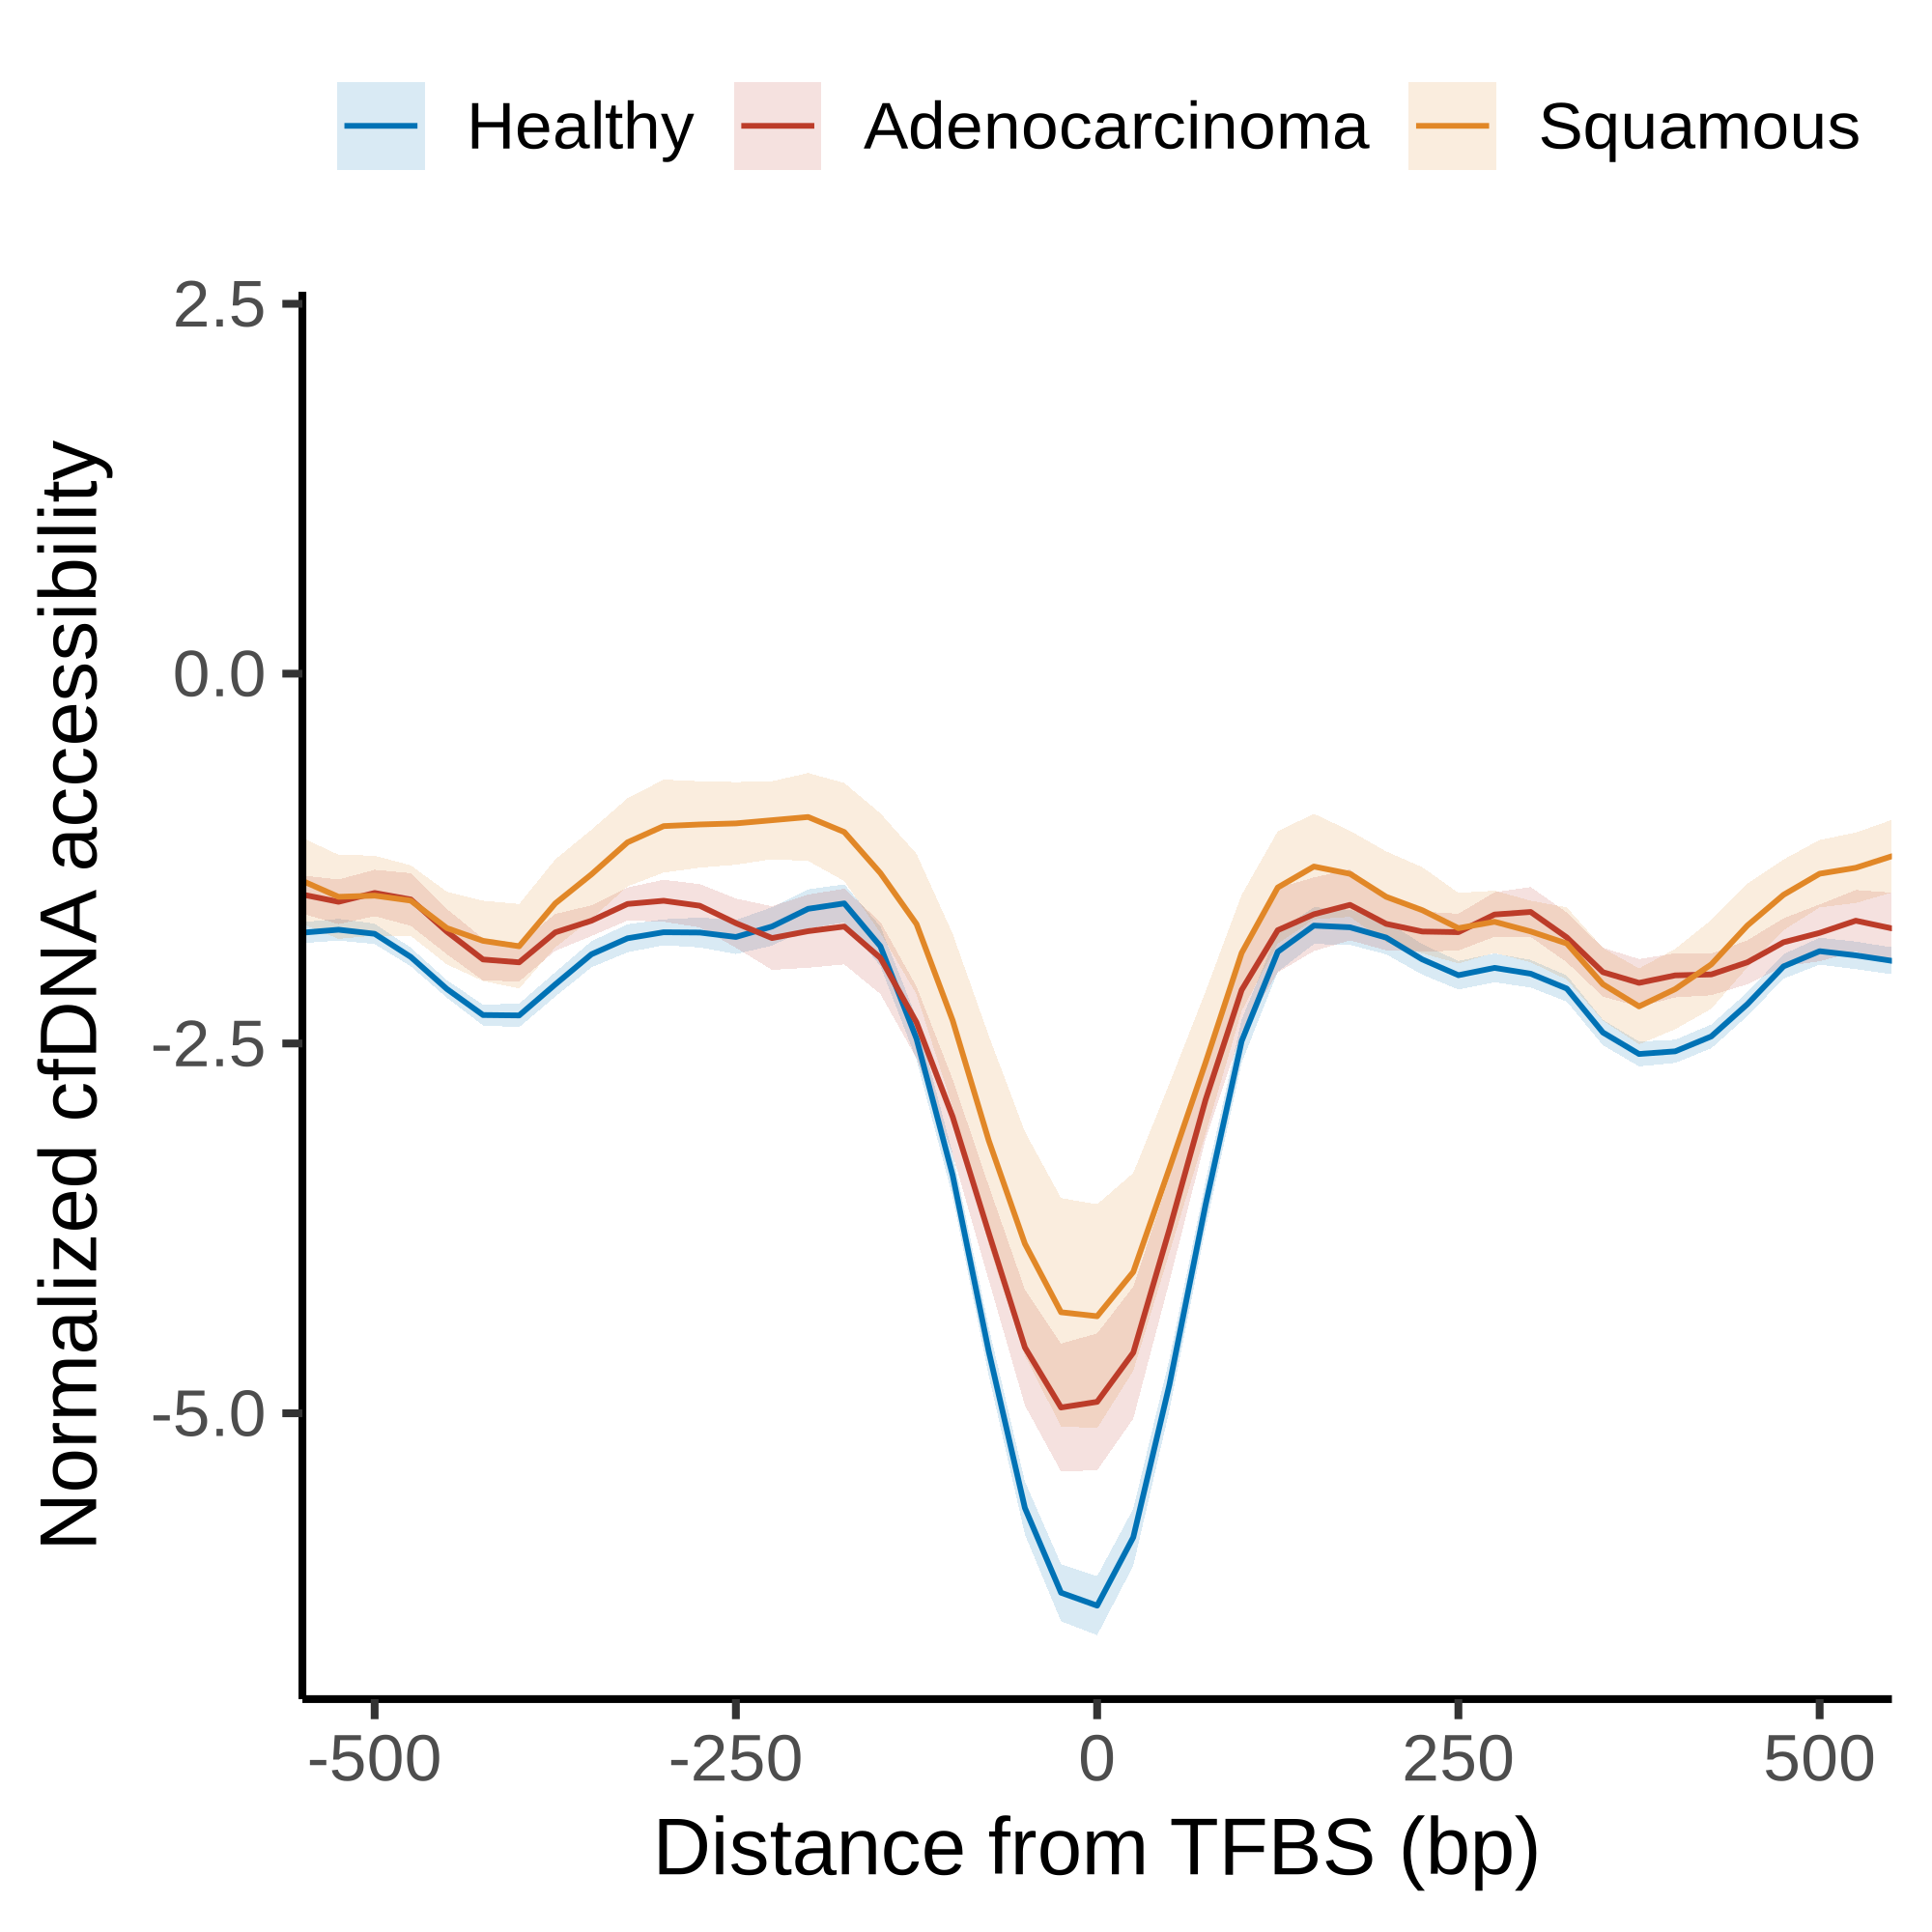

In [10]:
# Get list of individual plots
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 200)

plot_list <- plot_tfbs_cfdna_styled(
  summary_df,
  ncol = 1,
  base_size = 30,
  add_nrl_markers = FALSE,
  x_lim = c(-500, 500),
  return_list = TRUE
)

# See available TF names
names(plot_list)

# Plot individual TFs by name
plot_list[["MECOM"]]

# Or by index
#plot_list[[1]]



In [11]:
ggsave(
  filename = "../../outputs/Fig4/Fig-TF-LYL1-V2.png",
  plot = plot_list[["LYL1"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)


ggsave(
  filename = "../../outputs/Fig4/Fig-TF-GRHL2-V2.png",
  plot = plot_list[["GRHL2"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)


ggsave(
  filename = "../../outputs/Fig4/Fig-TF-FOXA1-V2.png",
  plot = plot_list[["FOXA1"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)

ggsave(
  filename = "../../outputs/Fig4/Fig-TF-MECOM-V2.png",
  plot = plot_list[["MECOM"]],
  width = 10,
  height = 10,
  units = "in",
  dpi = 300,
  bg = "transparent"
)